In [1]:
import pandas as pd
import numpy as np

from lightgbm import LGBMRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv("../data/processed/master_dataset_features.csv")

In [3]:
df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_type_2,snap_CA,snap_TX,snap_WI,day,sell_price,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,No Event,0,0,0,29,0.0,0.0,0.0,0.0,0.0
1,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_2,0,2011-01-30,11101,...,No Event,0,0,0,30,0.0,0.0,0.0,0.0,0.0
2,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_3,0,2011-01-31,11101,...,No Event,0,0,0,31,0.0,0.0,0.0,0.0,0.0
3,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_4,0,2011-02-01,11101,...,No Event,1,1,0,1,0.0,0.0,0.0,0.0,0.0
4,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_5,0,2011-02-02,11101,...,No Event,1,0,1,2,0.0,0.0,0.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 956500 entries, 0 to 956499
Data columns (total 27 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              956500 non-null  str    
 1   item_id         956500 non-null  str    
 2   dept_id         956500 non-null  str    
 3   cat_id          956500 non-null  str    
 4   store_id        956500 non-null  str    
 5   state_id        956500 non-null  str    
 6   d               956500 non-null  str    
 7   sales           956500 non-null  int64  
 8   date            956500 non-null  str    
 9   wm_yr_wk        956500 non-null  int64  
 10  weekday         956500 non-null  str    
 11  wday            956500 non-null  int64  
 12  month           956500 non-null  int64  
 13  year            956500 non-null  int64  
 14  event_name_1    956500 non-null  str    
 15  event_type_1    956500 non-null  str    
 16  event_name_2    956500 non-null  str    
 17  event_type_2    95650

In [5]:
features = [
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "sell_price",
    "month",
    "year",
    "day"
]

In [6]:
X = df[features]

y = df["sales"]

In [7]:
X = X.fillna(0)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = LGBMRegressor(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033430 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 835
[LightGBM] [Info] Number of data points in the train set: 765200, number of used features: 8
[LightGBM] [Info] Start training from score 0.892211


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [10]:
predictions = model.predict(X_test)

In [11]:
mae = mean_absolute_error(
    y_test,
    predictions
)

print("MAE:", mae)

MAE: 0.7353858386736984


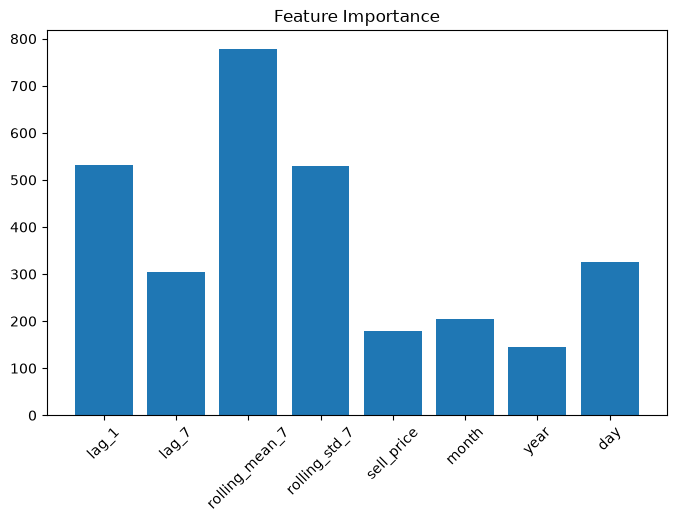

In [12]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(8,5))

plt.bar(
    features,
    importance
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

In [13]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

results.to_csv(
    "../data/processed/lightgbm_predictions.csv",
    index=False
)

In [14]:
import joblib

joblib.dump(
    model,
    "../models/lightgbm_model.pkl"
)

['../models/lightgbm_model.pkl']

## LightGBM Model Summary

A LightGBM regression model was trained using engineered features such as lag values, rolling averages, selling price, and calendar information. The model predicts product sales and identifies which features have the greatest impact on demand.